## Metody redukcji wymiaru: Principal Component Analysis (PCA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

### analiza zbioru danych New YorkTimes

In [3]:
# 1. Załaduj zbiór danych NYT jako DataFrame (biblioteka Pandas)
df = pd.read_csv("./nyt-frame.csv", header = 0)
data = df.iloc[:,9:].values
header = list(df.columns.values[9:])

# 2. Wyświetl 20 losowych wybranych elementów słownika (nagłówek)
sample_word = np.random.choice(header, 20, replace=False)
print(f"Sample words: {sample_word}")


Sample words: ['registry' 'islip' 'police' 'impressive' 'distinctive' 'nashville'
 'retrospective' 'fund' 'awareness' 'artwork' 'pulse' 'partner' 'could'
 'his' 'here' 'staged' 'opening' 'learn' 'groom' 'intent']


In [4]:
# 3. Dokonaj transformacji PCA pomijając kolumny, które nie reprezentują
# słów a jedynie metadane

pca = PCA()
X_pca = pca.fit_transform(data)

4. Dla pierwszego komponentu wiodącego wyświetl 15 elementów o najwięszej wartości (wraz z nazwami kolumn - słowami). Jakim słowom odpowiadają największe wartości pierwszego komponentu wiodącego?
5. Dla pierwszego komponentu wiodącego wyświetl 15 elementów o najmniejszej wartości (wraz z nazwami kolumn - słowami). Jakim słowom
odpowiadają najmniejsze wartości pierwszego komponentu wiodącego?
6. Powtórz eksperyment dla drugiego komponentu wiodącego. Skomentuj
uzyskane wyniki.

In [5]:
# Component 1 - biggest and smallest elements
pc1 = pca.components_[0]
idx_max = np.argsort(pc1)[-15:]
idx_min = np.argsort(pc1)[:15]

print("Top 15 +PC1 words:", [header[i] for i in idx_max])
print("Top 15 -PC1 words:", [header[i] for i in idx_min])

# Component 2 - biggest and smallest elements
pc2 = pca.components_[1]
idx_max2 = np.argsort(pc2)[-15:]
idx_min2 = np.argsort(pc2)[:15]

print("Top 15 +PC2 words:", [header[i] for i in idx_max2])
print("Top 15 -PC2 words:", [header[i] for i in idx_min2])

Top 15 +PC1 words: ['me', 'he', 'mrs', 'im', 'paintings', 'process', 'painting', 'my', 'cooper', 'mother', 'said', 'i', 'ms', 'her', 'she']
Top 15 -PC1 words: ['music', 'trio', 'theater', 'orchestra', 'composers', 'opera', 'theaters', 'm', 'program', 'players', 'festival', 'east', 'y', 'jersey', 'symphony']
Top 15 +PC2 words: ['vocal', 'orchestra', 'songs', 'musical', 'music', 'festival', 'production', 'sang', 'hour', 'i', 'ms', 'opera', 'theater', 'she', 'her']
Top 15 -PC2 words: ['art', 'museum', 'images', 'artists', 'donations', 'museums', 'painting', 'tax', 'paintings', 'sculpture', 'gallery', 'sculptures', 'painted', 'white', 'service']


+PC1 - głownie zaimki

-PC1 - słowa związane ze sztuką, muzyką

+PC2 - słowa związane z muzyką

-PC2 - słowa związane z malowaniem, muzeami

7. Dokonaj wizualizacji wektorów cech zrzutowanych na 2(3) pierwsze komponenty wiodące. Zaznacz dwie klasy (art, music) oddzielnymi kolorami

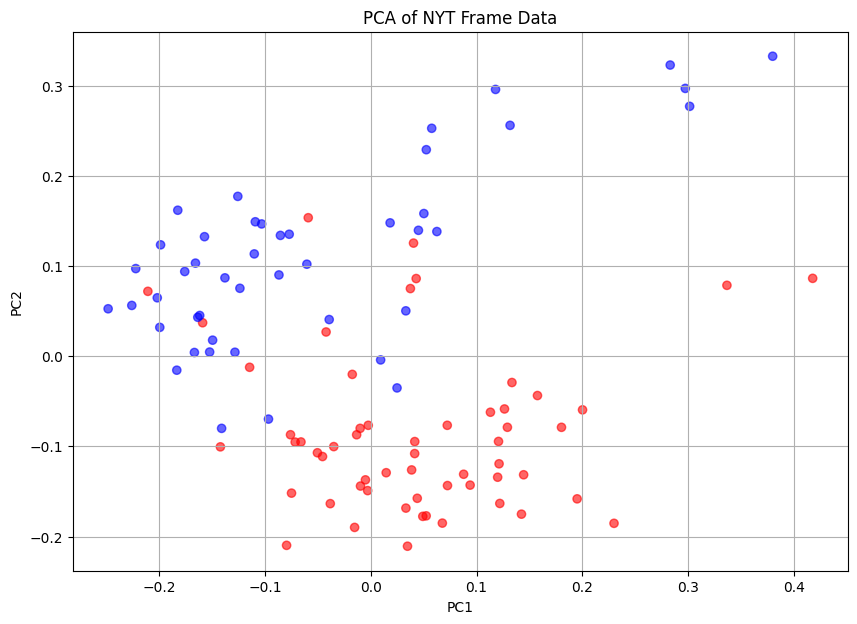

In [6]:
# Visualize the PCA results
labels = df['class.labels'].values
colors = ['red' if l=='art' else 'blue' for l in labels]

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of NYT Frame Data')
plt.grid(True)
plt.show()

8. Narysuj wykres zależności wartości wariancji od numeru kierunku wiodącego k. Jaka część wariancji zostaje zachowana po wykonaniu projekcji
na pierwsze 10 komponentów wiodących?

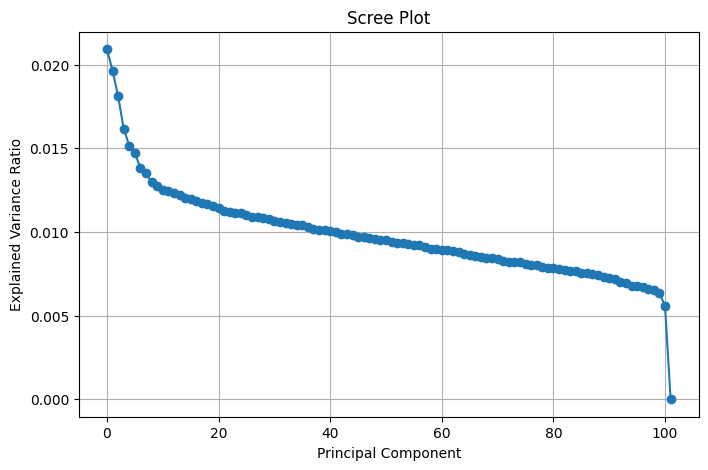

Cumulative explained variance for first 10 components: 0.1577


In [7]:
# explained variance ratio
variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(variance_ratio, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.title('Scree Plot')
plt.show()

cumulative_variance = np.cumsum(variance_ratio)
print(f"Cumulative explained variance for first 10 components: {cumulative_variance[9].round(4)}")

9. Skomentuj w jaki sposób inne niż domyśle wartości argumentów konstruktora sklearn.decomposition.PCA mogą być przydatne w rozwiązaniu
tego zadania:
— n components: None, int, float, ’mle’
— copy
— whiten
— svd solver: ’auto’, ’full’, ’arpack’, ’randomized’

* n components: int -> pozwala na sztywne określenie liczby wymiarów. Jest kluczowe w zadaniu 7, gdzie rzutujemy dane na dokładnie 2 lub 3 komponenty w celu ich wizualizacji na płaszczyźnie lub w przestrzeni.
float -> automatycznie dobiera liczbę komponentów tak, aby wyjaśnić określony procent wariancji
'mle' _> wykorzystuje algorytm Minka do estymacji „prawdziwego” wymiaru danych. Może być przydatne do automatycznego odfiltrowania szumu w słowniku NYT bez ręcznego analizowania wykresów.

* copy -> Przy ustawieniu False dane wejściowe są nadpisywane, co pozwala zaoszczędzić pamięć RAM. W przypadku bardzo dużych macierzy słów (jak nyt-frame.csv, który ma tysiące kolumn), wyłączenie kopiowania może zapobiec błędowi braku pamięci

* whiten -> Wybielanie (True) skaluje wektory komponentów tak, aby każdy miał jednostkową wariancję. Może to być przydatne, jeśli po wykonaniu PCA planujemy użyć algorytmu, który jest wrażliwy na skalę cech

###  analiza zbioru danych 04Cars

In [10]:
df_cars = pd.read_csv("./04cars-data.csv", header=0)
data = df_cars.iloc[:, 9:]
data.shape

(387, 11)

2. Znormalizuj dane, zapewniając, że dla każdej cechy średnia arytmetyczne
wynosi 0, a wariancja 1.

In [11]:
data_scaled = scale(data)

In [12]:
data_scaled.mean(axis=0)

array([-4.13106242e-17,  4.13106242e-17, -6.05889155e-16, -1.00981526e-16,
       -1.79012705e-16, -4.59006935e-18, -7.57361443e-17, -2.06553121e-16,
        7.89491929e-16, -6.70150125e-16,  1.78094691e-15])

In [13]:
data_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

3. Dokonaj transformacji PCA dla wejściowego zbioru danych, a następnie przedstaw zależność bezwzględnej i względnej wartości wariancji od numeru kierunku wiodącego k. Jaka część wariancji zostaje zachowana przy redukcji wymiarowości do 2 i 3 

In [14]:
pca = PCA()
X_pca = pca.fit_transform(data_scaled)
print(pca.explained_variance_ratio_)

[6.45876221e-01 1.71265888e-01 7.72480259e-02 3.24559536e-02
 2.50395994e-02 1.79948832e-02 1.27744735e-02 7.87625563e-03
 6.03527097e-03 3.36157838e-03 7.18504308e-05]


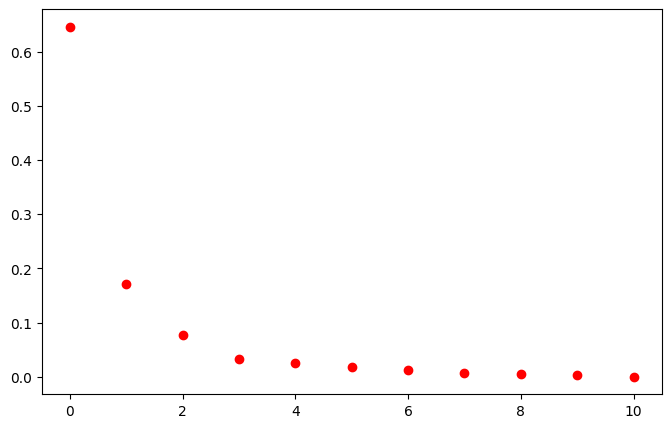

In [15]:
variance_ratio = pca.explained_variance_ratio_
plt.figure(figsize=(8, 5))
plt.plot(variance_ratio,'ro')
plt.show()

In [17]:
print(pca.explained_variance_ratio_[:10])
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"Wariancja zachowana (2 składowe): {cumulative_variance[1]:.2%}")
print(f"Wariancja zachowana (3 składowe): {cumulative_variance[2]:.2%}")

[0.64587622 0.17126589 0.07724803 0.03245595 0.0250396  0.01799488
 0.01277447 0.00787626 0.00603527 0.00336158]
Wariancja zachowana (2 składowe): 81.71%
Wariancja zachowana (3 składowe): 89.44%


4. Wyświetl wartości elementów pierwszego i drugiego komponentu wiodącego wraz z odpowiadającą im nazwą cechy. Co oznaczają elementy o wartości bliskiej zeru? Z jakimi własnościami samochodu wiążą się:
* Największe elementy pierwszego komponentu wiodącego
* Najmniejsze elementy pierwszego komponentu wiodącego
* Największe elementy drugiego komponentu wiodącego
* Najmniejsze elementy drugiego komponentu wiodącego

In [18]:
attributes = df_cars.columns.values[9:]

In [21]:
df_components = pd.DataFrame({
    'Attribute': df_cars.columns[9:],
    'PC1': pca.components_[0],
    'PC2': pca.components_[1]
})

df_components = df_components.set_index('Attribute')
df_components.round(3)

,PC1,PC2
Attribute,,
Retail Price,0.264,0.469
Dealer Cost,0.262,0.470
Engine Size (l),0.347,-0.015
Cyl,0.334,0.078
HP,0.319,0.292
City MPG,-0.310,-0.003
Hwy MPG,-0.307,-0.011
Weight,0.336,-0.167
Wheel Base,0.266,-0.418


* Największe elementy PC1 (Engine Size, Weight, Cyl, HP):
Wiążą się z ogólną mocą i masą samochodu. Wysokie wartości PC1 wskazują na pojazdy o dużych silnikach, dużej liczbie cylindrów i wysokiej masie.
* Najmniejsze elementy PC1 (City MPG, Hwy MPG):
Wiążą się ze spalaniem paliwa. Ujemne wartości oznaczają, że cechy te zmieniają się w przeciwnym kierunku do mocy i wagi.
* Największe elementy PC2 (Retail Price, Dealer Cost):
Wiążą się z ceną. Drugi komponent w swojej dodatniej części wyodrębnia samochody drogie, niezależnie od ich fizycznych rozmiarów.
* Najmniejsze elementy PC2 (Wheel Base, Len, Width):
Wiążą się z wymiarami samochodów. Przykładowo, auto sportowe będzie miało wysokie PC2, podczas gdy van będzie miało niskie (ujemne) wartości PC2.

Elementy o wartości bliskiej zeru oznaczają, że dany atrybut ma znikomy wpływ na ten konkretny komponent

5. Dokonaj wizualizacji wektorów cech zrzutowanych na 2(3) pierwsze komponenty wiodące. Nanieś tekst z modelem samochodu na wykres. Jakie typy samochodów występują w poszczególnych częściach wykresu?

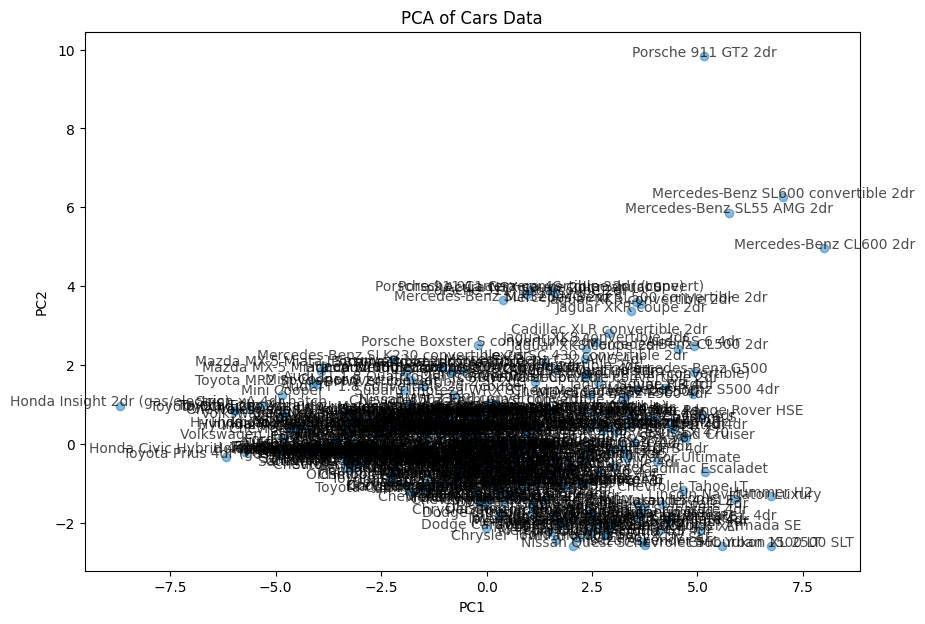

In [22]:
plt.figure(figsize=(10, 7))
x = X_pca[:, 0]
y = X_pca[:, 1]

plt.scatter(x, y, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Cars Data')
labels = list(df_cars.iloc[:, 0])
for i, txt in enumerate(labels):
    plt.annotate(txt, (x[i], y[i]), ha= 'center', alpha=0.7)

plt.show()

* Lewa strona (Ujemne PC1) - auta miejskie i ekonomiczne
* Prawa strona (Dodatnie PC1) - auta o dużej masie i mocy, silniku (auta sportowe + duże auta jak busy)
* Dół (Ujemne PC2) - duże auta
* Góra (Dodatnie PC2) - auta sportowe

Na tym samym wykresie w 2D przedstaw zbiór danych o zredukowanym
rozmiarze wraz z wizualicacją cech zrzutowanych na 2 pierwsze komponenty wiodące (biplot). Co pokazuje tego typu wizualizacja?

In [34]:
#biplot
def my_plot(score, coeff, labels=None):
    plt.figure(figsize=(25, 18))
    plt.xlabel("PC{}".format(1))
    plt.ylabel("PC{}".format(2))
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    plt.scatter(xs * scalex, ys * scaley, c = y)
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color = 'r', alpha = 0.5)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')

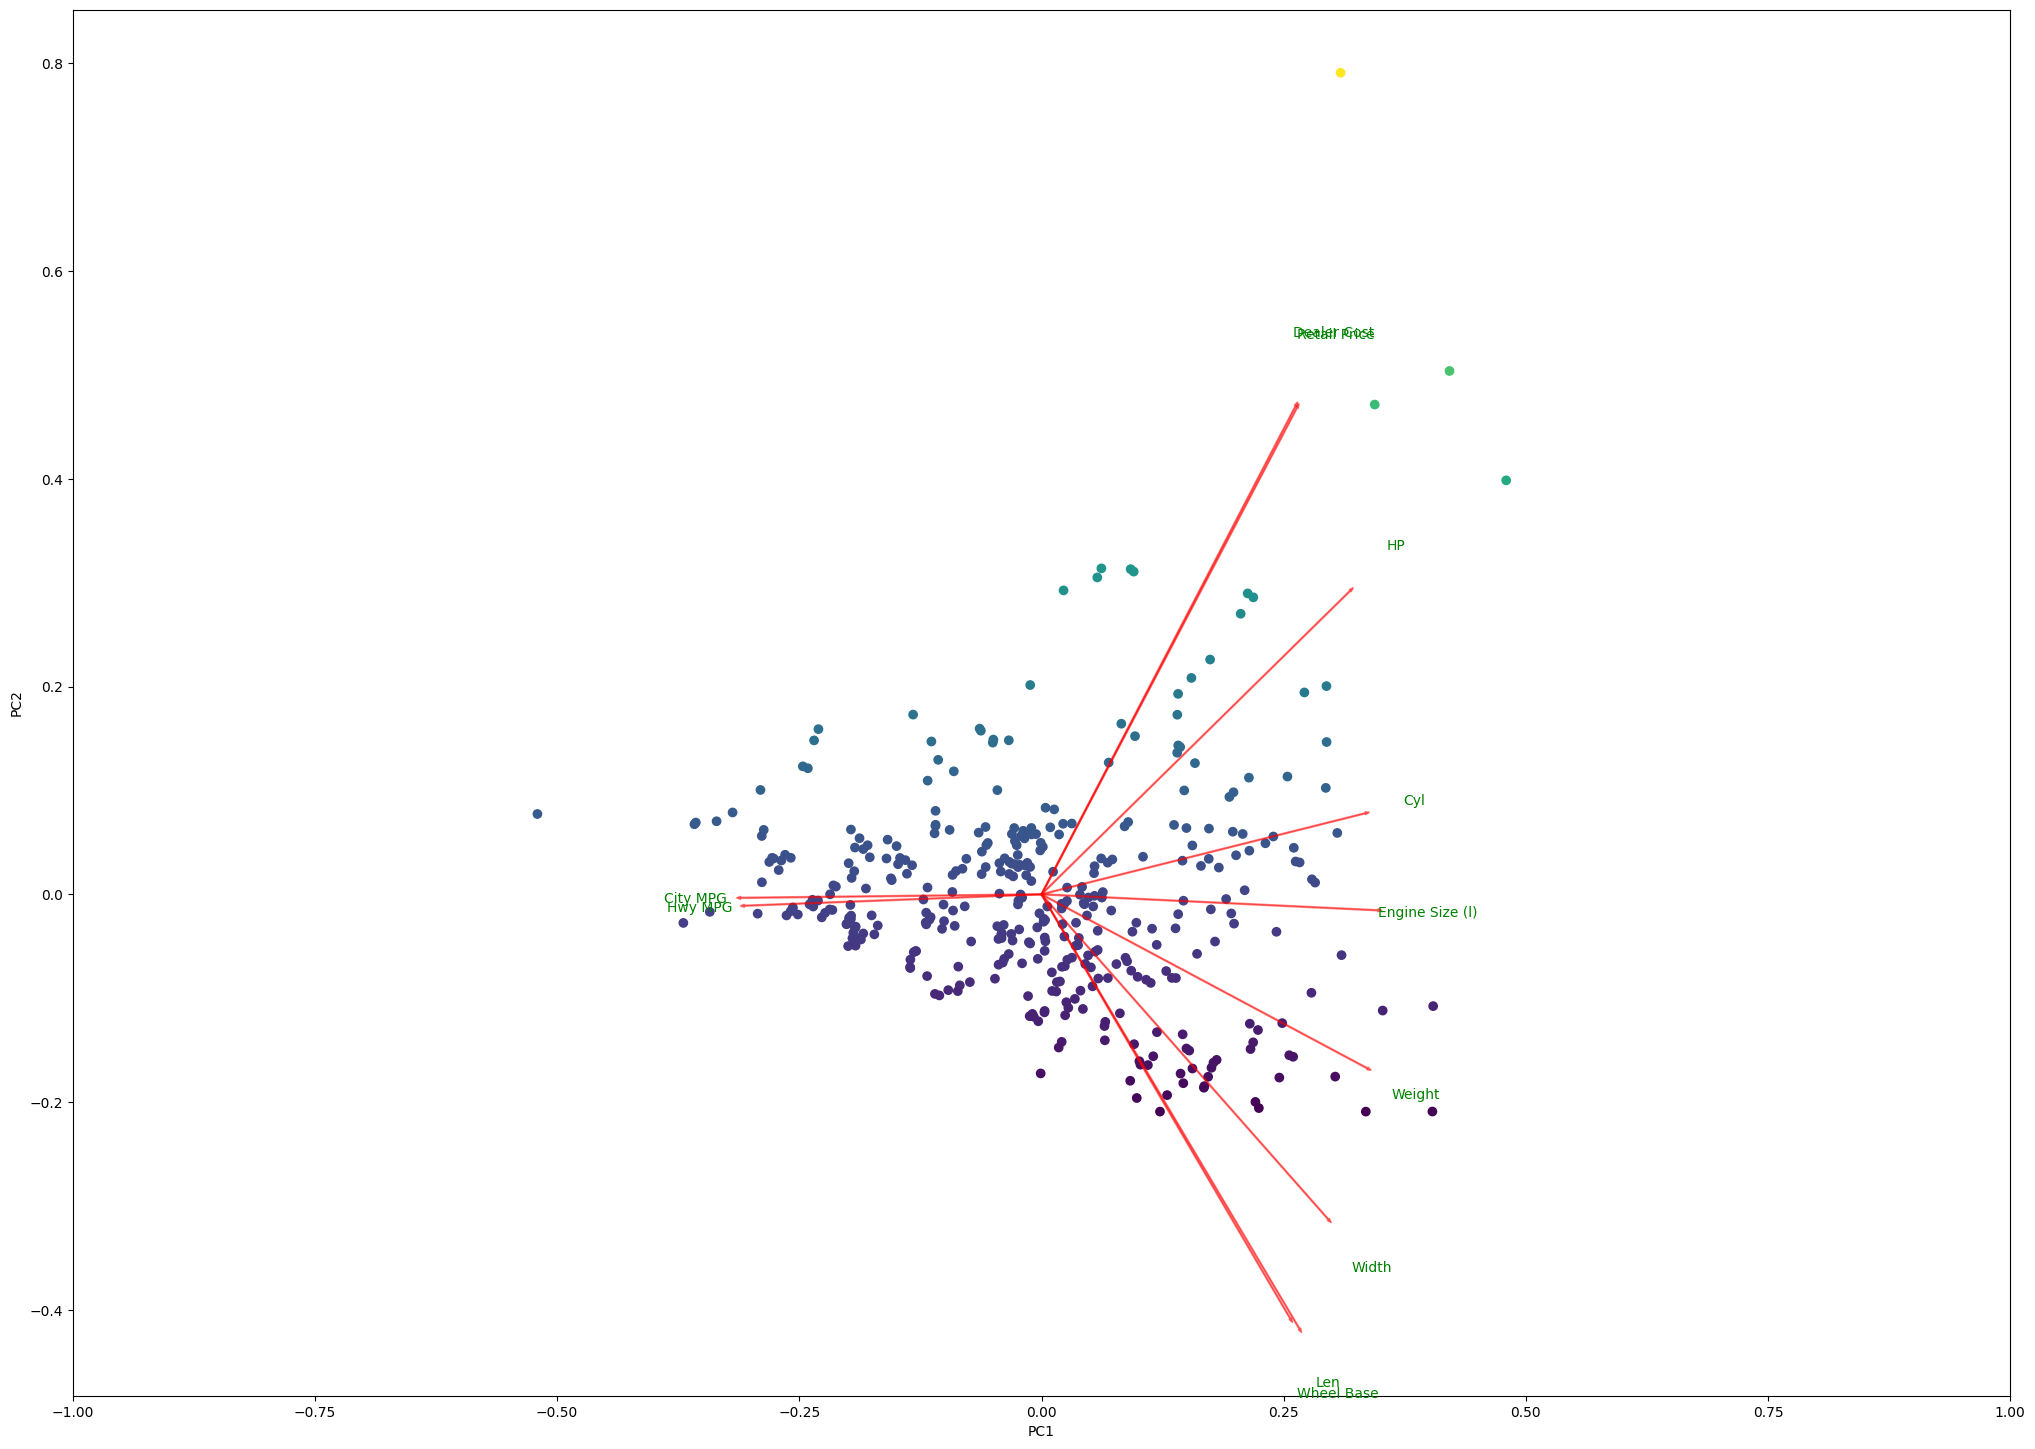

In [36]:
my_plot(X_pca[:,0:2], np.transpose(pca.components_[0:2, :]), labels=attributes)
axes = plt.gca()
axes.set_xlim([-1.0,1.0])
plt.show()

Wykres pozwala zobaczyć, które cechy są ze sobą skorelowane (np. wielkość silnika i liczba cylindrów są ze sobą skorelowane, poniważ kąt między wektorami jest mały) i jak silnie są skorelowane z PC1 i PC2(np. wielkość silnika jest skorelowana z PC1 ponieważ jest równoległa do osi PC1).

###  Budowa eigenfaces w oparciu o zbiór danych LFW

1. Korzystając z biblioteki scikit-learn wczytaj podzbiór zbioru danych
LFW składający się z osób reprezentowanych przez co najmniej 50 różnych zdjęć (fetch lfw people()). W ten sposób otrzymasz zbiór zdjęć 12 różnych osób.

In [23]:
from sklearn.datasets import fetch_lfw_people

lfw_people = fetch_lfw_people(min_faces_per_person=50, resize=0.4)

n_samples, h, w = lfw_people.images.shape
X = lfw_people.data
n_features = X.shape[1]
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print(f"Liczba próbek (zdjęć): {n_samples}")
print(f"Wymiary obrazka: {h}x{w} pikseli")
print(f"Liczba cech (pikseli): {n_features}")
print(f"Liczba osób: {n_classes}")
print(f"Nazwy osób: {target_names}")

Liczba próbek (zdjęć): 1560
Wymiary obrazka: 50x37 pikseli
Liczba cech (pikseli): 1850
Liczba osób: 12
Nazwy osób: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Jacques Chirac' 'Jean Chretien'
 'John Ashcroft' 'Junichiro Koizumi' 'Serena Williams' 'Tony Blair']


2. Podziel otrzymany zbiór danych na część treningową i testową (0.7, 0.3)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Liczba zdjęć w zbiorze treningowym: {X_train.shape[0]}")
print(f"Liczba zdjęć w zbiorze testowym: {X_test.shape[0]}")

Liczba zdjęć w zbiorze treningowym: 1092
Liczba zdjęć w zbiorze testowym: 468


3. Dla zbioru treningowego, oblicz PCA i opierając się na otrzymanych
w ten sposób 100 pierwszych komponentach głównych dokonaj redukcji
wymiarowości do 100 dla zbioru treningowego i testowego.

In [25]:
n_components = 100
pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True).fit(X_train)
eigenfaces = pca.components_.reshape((n_components, h, w))
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print(f"Nowy wymiar zbioru treningowego: {X_train_pca.shape}")
print(f"Nowy wymiar zbioru testowego: {X_test_pca.shape}")

Nowy wymiar zbioru treningowego: (1092, 100)
Nowy wymiar zbioru testowego: (468, 100)


4. Korzystając ze zbioru treningowego o zredukowanej wymiarowości, wytrenuj dwa wybrane modele klasyfikacji (np. MLP, SVM, RF, LightGBM)
oraz oblicz dokładność klasyfikacji uzyskaną dla każdej z 12 klas na zbiorze testowym. Zamieść w raporcie uzyskane wartości: precision, recall,
f1-score. Jak zmieniają się uzyskane wyniki w przypadku redukcji do 50
wymiarów? Wybierz optymalną wymiarowość w oparciu o scree plot

In [39]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# SVM
svm_model = SVC(kernel='rbf', class_weight='balanced', C=10, gamma=0.01)
svm_model.fit(X_train_pca, y_train)

y_pred_svm = svm_model.predict(X_test_pca)

print("\n" + "="*20 + " WYNIKI SVM " + "="*20)
print(classification_report(y_test, y_pred_svm, target_names=target_names))



==================== WYNIKI SVM ====================
                   precision    recall  f1-score   support

     Ariel Sharon       0.88      0.61      0.72        23
     Colin Powell       0.81      0.86      0.84        71
  Donald Rumsfeld       0.83      0.67      0.74        36
    George W Bush       0.72      0.97      0.83       159
Gerhard Schroeder       0.83      0.76      0.79        33
      Hugo Chavez       1.00      0.52      0.69        21
   Jacques Chirac       0.86      0.38      0.52        16
    Jean Chretien       0.92      0.69      0.79        16
    John Ashcroft       0.85      0.69      0.76        16
Junichiro Koizumi       1.00      0.56      0.71        18
  Serena Williams       1.00      0.56      0.72        16
       Tony Blair       0.72      0.72      0.72        43

         accuracy                           0.78       468
        macro avg       0.87      0.66      0.74       468
     weighted avg       0.81      0.78      0.78       468


In [44]:
rf_model = RandomForestClassifier(n_estimators=500, max_depth=5, random_state=42, class_weight='balanced')
rf_model.fit(X_train_pca, y_train)

# Predykcja RF
y_pred_rf = rf_model.predict(X_test_pca)


print("\n" + "="*20 + " WYNIKI RANDOM FOREST " + "="*20)
print(classification_report(y_test, y_pred_rf, target_names=target_names))


==================== WYNIKI RANDOM FOREST ====================
                   precision    recall  f1-score   support

     Ariel Sharon       0.33      0.52      0.41        23
     Colin Powell       0.70      0.55      0.61        71
  Donald Rumsfeld       0.38      0.83      0.53        36
    George W Bush       0.89      0.47      0.61       159
Gerhard Schroeder       0.72      0.39      0.51        33
      Hugo Chavez       0.39      0.76      0.52        21
   Jacques Chirac       0.17      0.19      0.18        16
    Jean Chretien       0.56      0.62      0.59        16
    John Ashcroft       0.27      0.50      0.35        16
Junichiro Koizumi       0.46      0.61      0.52        18
  Serena Williams       0.57      0.81      0.67        16
       Tony Blair       0.65      0.65      0.65        43

         accuracy                           0.55       468
        macro avg       0.51      0.58      0.51       468
     weighted avg       0.65      0.55      0.56 

Wyniki dla SVM są dużo lepsze niż dla RF, które zupełnie sobie nie radzi, więc w dalszej analizie będę używać jedynie SVM

In [45]:
pca_50 = PCA(n_components=50, svd_solver='randomized', whiten=True).fit(X_train)
X_train_50 = pca_50.transform(X_train)
X_test_50 = pca_50.transform(X_test)

svm_model2 = SVC(kernel='rbf', class_weight='balanced', C=10, gamma=0.01)
svm_model2.fit(X_train_50, y_train)

y_pred_svm2 = svm_model2.predict(X_test_50)

print("\n" + "="*20 + " WYNIKI SVM " + "="*20)
print(classification_report(y_test, y_pred_svm2, target_names=target_names))


==================== WYNIKI SVM ====================
                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.74      0.69        23
     Colin Powell       0.87      0.85      0.86        71
  Donald Rumsfeld       0.70      0.72      0.71        36
    George W Bush       0.86      0.91      0.89       159
Gerhard Schroeder       0.63      0.73      0.68        33
      Hugo Chavez       0.84      0.76      0.80        21
   Jacques Chirac       0.82      0.56      0.67        16
    Jean Chretien       0.85      0.69      0.76        16
    John Ashcroft       0.81      0.81      0.81        16
Junichiro Koizumi       1.00      0.72      0.84        18
  Serena Williams       1.00      0.81      0.90        16
       Tony Blair       0.78      0.81      0.80        43

         accuracy                           0.82       468
        macro avg       0.82      0.76      0.78       468
     weighted avg       0.82      0.82      0.82       468


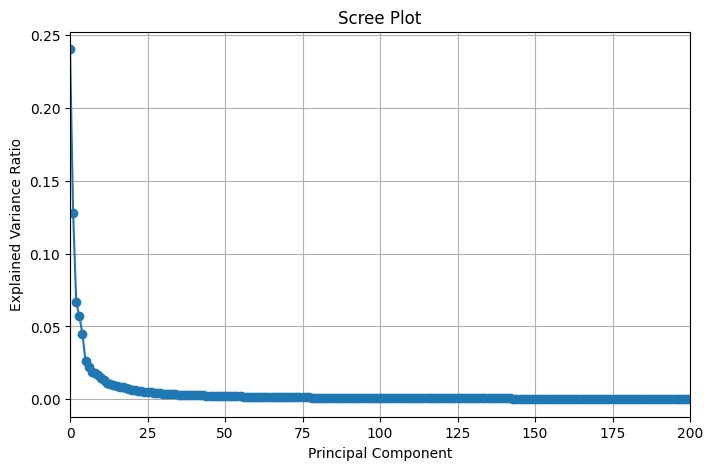

In [48]:

pca_full = PCA(svd_solver='randomized', whiten=True).fit(X_train)

variance_fullpca = pca_full.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(variance_fullpca, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xlim(0, 200)
plt.title('Scree Plot')
plt.show()


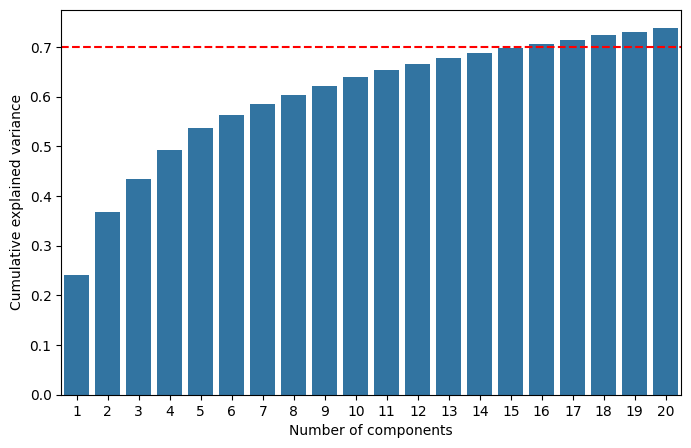

In [58]:
# Skumulowana zmienność
plt.figure(figsize=(8, 5))
sns.barplot(x=np.arange(1,21), y=np.cumsum(pca_full.explained_variance_ratio_)[:20])
plt.axhline(y=0.7, color='r', linestyle='--', label='70% Wariancji')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

15 głownych składowych opisuje 70% wariancji

In [59]:
pca_15 = PCA(n_components=15, svd_solver='randomized', whiten=True).fit(X_train)
X_train_15 = pca_15.transform(X_train)
X_test_15 = pca_15.transform(X_test)

svm_model3 = SVC(kernel='rbf', class_weight='balanced', C=10, gamma=0.01)
svm_model3.fit(X_train_15, y_train)

y_pred_svm3 = svm_model3.predict(X_test_15)

print("\n" + "="*20 + " WYNIKI SVM " + "="*20)
print(classification_report(y_test, y_pred_svm3, target_names=target_names))


==================== WYNIKI SVM ====================
                   precision    recall  f1-score   support

     Ariel Sharon       0.23      0.35      0.28        23
     Colin Powell       0.53      0.39      0.45        71
  Donald Rumsfeld       0.49      0.47      0.48        36
    George W Bush       0.85      0.58      0.69       159
Gerhard Schroeder       0.50      0.52      0.51        33
      Hugo Chavez       0.36      0.62      0.46        21
   Jacques Chirac       0.17      0.38      0.23        16
    Jean Chretien       0.40      0.62      0.49        16
    John Ashcroft       0.21      0.44      0.29        16
Junichiro Koizumi       0.69      0.50      0.58        18
  Serena Williams       0.75      0.94      0.83        16
       Tony Blair       0.56      0.51      0.54        43

         accuracy                           0.52       468
        macro avg       0.48      0.53      0.48       468
     weighted avg       0.60      0.52      0.55       468


Najwyższe wyniki wyszły dla modelu SVM 2, czyli w przypadku redukcji do 50 wymiarów

5. Wyświetl 20 pierwszych komponentów głównych (po uprzednim przeskalowaniu) w formie obrazu w skali szarości (eigenfaces). W jaki sposób
można zinterpretować działanie eigenfaces w kontekście redukcji wymiarowości wcześniej nie widzianego zdjęcia (przykładu testowego)? Jakie
cechy ekstrahują poszczególe eigenfaces?


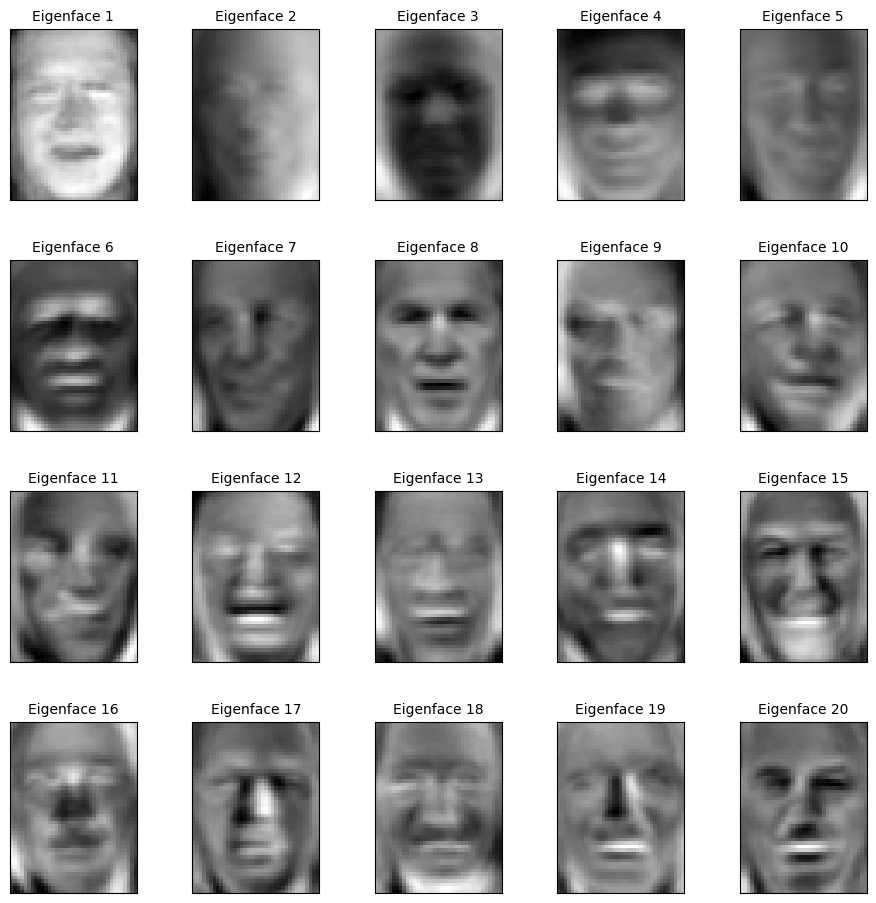

In [60]:
def plot_gallery(images, titles, h, w, n_row=4, n_col=5):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=10)
        plt.xticks(())
        plt.yticks(())

eigenface_titles = [f"Eigenface {i+1}" for i in range(20)]

plot_gallery(pca.components_[:20], eigenface_titles, h, w)
plt.show()

### Zadanie dodatkowe: Kernel PCA

Artykuł opisuje problem klasyfikacji danych, które w oryginalnej przestrzeni (3D) są całkowicie nieseparowalne liniowo – jedna sfera znajduje się wewnątrz drugiej.Dane: 1000 punktów. 500 punktów na sferze o promieniu $r_1 = 40$ (Klasa 1) i 500 punktów na sferze o promieniu $r_2 = 100$ (Klasa 2). Dodano szum gaussowski o $\sigma = 1$.Problem: Klasyczna metoda PCA (liniowa) jedynie rzutuje sfery na płaszczyznę, zachowując ich "nakładanie się" (okrąg wewnątrz okręgu). Żadna płaszczyzna ani linia nie jest w stanie ich oddzielić.Rozwiązanie: Zastosowanie funkcji jądra (Kernel) pozwala przenieść dane do przestrzeni o bardzo wysokim wymiarze, w której odległości między punktami są przeliczane nieliniowo. W tej nowej przestrzeni punkty z różnych sfer "rozsuwają się", stając się separowalnymi liniowo.

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from mpl_toolkits.mplot3d import Axes3D

In [62]:
np.random.seed(42)
N = 1000
n_class = N // 2
r1, r2 = 40, 100
sigma_noise = 1

def generate_sphere(r, n, sigma):
    theta = np.random.uniform(0, np.pi, n)
    phi = np.random.uniform(0, 2 * np.pi, n)
    x = r * np.sin(theta) * np.cos(phi) + np.random.normal(0, sigma, n)
    y = r * np.sin(theta) * np.sin(phi) + np.random.normal(0, sigma, n)
    z = r * np.cos(theta) + np.random.normal(0, sigma, n)
    return np.column_stack([x, y, z])

class1 = generate_sphere(r1, n_class, sigma_noise)
class2 = generate_sphere(r2, n_class, sigma_noise)
X = np.vstack([class1, class2])
y = np.array([0] * n_class + [1] * n_class)

In [82]:
# PCA Liniowe
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Kernel PCA - RBF (parametr gamma dobrany empirycznie)
kpca_rbf = KernelPCA(n_components=2, kernel='rbf', gamma=0.001)
X_kpca_rbf = kpca_rbf.fit_transform(X)

# Kernel PCA - Polynomial (stopień 2)
kpca_poly = KernelPCA(n_components=2, kernel='poly', degree=2)
X_kpca_poly = kpca_poly.fit_transform(X)

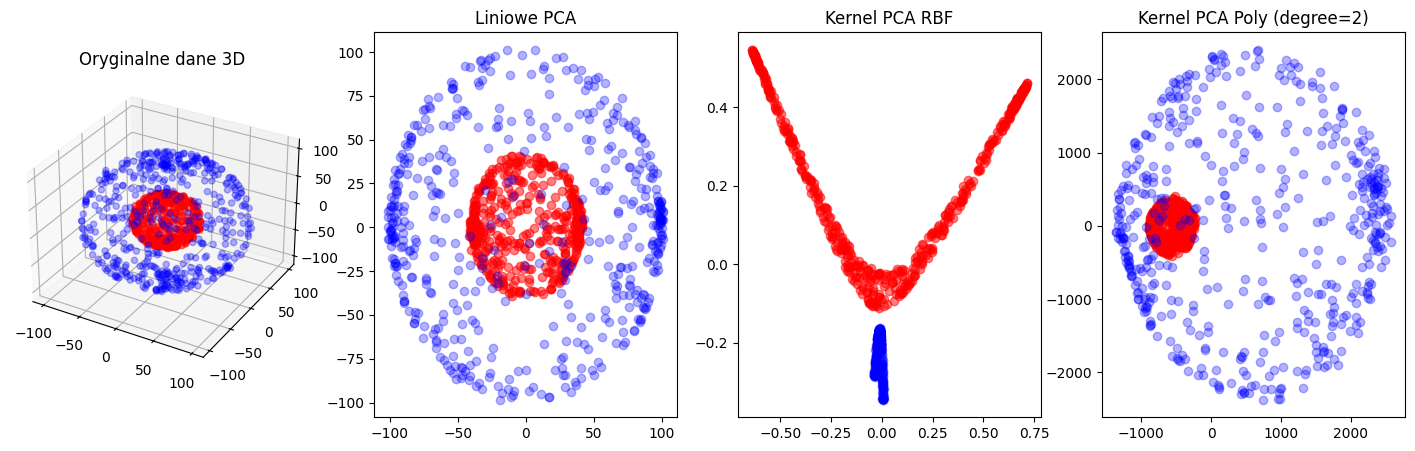

In [83]:
fig = plt.figure(figsize=(18, 5))

# Oryginalne dane 3D
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
ax1.scatter(class1[:,0], class1[:,1], class1[:,2], c='red', alpha=0.5, label='Sfera wewn.')
ax1.scatter(class2[:,0], class2[:,1], class2[:,2], c='blue', alpha=0.3, label='Sfera zewn.')
ax1.set_title("Oryginalne dane 3D")

# Wynik Liniowego PCA
ax2 = fig.add_subplot(1, 4, 2)
ax2.scatter(X_pca[y==0, 0], X_pca[y==0, 1], c='red', alpha=0.5)
ax2.scatter(X_pca[y==1, 0], X_pca[y==1, 1], c='blue', alpha=0.3)
ax2.set_title("Liniowe PCA")

# Wynik KPCA RBF
ax3 = fig.add_subplot(1, 4, 3)
ax3.scatter(X_kpca_rbf[y==0, 0], X_kpca_rbf[y==0, 1], c='red', alpha=0.5)
ax3.scatter(X_kpca_rbf[y==1, 0], X_kpca_rbf[y==1, 1], c='blue', alpha=0.3)
ax3.set_title("Kernel PCA RBF")

# Wynik KPCA Poly
ax4 = fig.add_subplot(1, 4, 4)
ax4.scatter(X_kpca_poly[y==0, 0], X_kpca_poly[y==0, 1], c='red', alpha=0.5)
ax4.scatter(X_kpca_poly[y==1, 0], X_kpca_poly[y==1, 1], c='blue', alpha=0.3)
ax4.set_title("Kernel PCA Poly (degree=2)")

plt.show()

Sprawdź czy zastosowanie nieliniowej redukcji wymiaru za pomocą
Kernel PCA poprawi wyniki klasyfikacji w zadaniu 7.3, 7.4.

In [87]:
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler

kpca = KernelPCA(n_components=50, kernel='rbf', gamma=0.0001, n_jobs=-1)

X_train_kernel = kpca.fit_transform(X_train)
X_test_kernel = kpca.transform(X_test)

scaler = StandardScaler()
X_train_kernel = scaler.fit_transform(X_train_kernel)
X_test_kernel = scaler.transform(X_test_kernel)

svm_model_new = SVC(kernel='rbf', class_weight='balanced', C=10, gamma=0.01)
svm_model_new.fit(X_train_kernel, y_train)

y_pred_svm_new = svm_model_new.predict(X_test_kernel)

print("\n" + "="*20 + " WYNIKI KERNEL PCA (RBF) + SVM " + "="*20)
print(classification_report(y_test, y_pred_svm_new, target_names=target_names))


==================== WYNIKI KERNEL PCA (RBF) + SVM ====================
                   precision    recall  f1-score   support

     Ariel Sharon       0.63      0.74      0.68        23
     Colin Powell       0.86      0.83      0.84        71
  Donald Rumsfeld       0.72      0.72      0.72        36
    George W Bush       0.87      0.92      0.89       159
Gerhard Schroeder       0.63      0.73      0.68        33
      Hugo Chavez       0.94      0.76      0.84        21
   Jacques Chirac       0.75      0.56      0.64        16
    Jean Chretien       0.79      0.69      0.73        16
    John Ashcroft       0.81      0.81      0.81        16
Junichiro Koizumi       0.93      0.72      0.81        18
  Serena Williams       1.00      0.75      0.86        16
       Tony Blair       0.76      0.79      0.77        43

         accuracy                           0.81       468
        macro avg       0.81      0.75      0.77       468
     weighted avg       0.82      0.81  

Metryki są trochę lepsze w przypadku użycia kernel PCA + SVM niż linear PCA + SVM